In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
try:
    df = pd.read_csv('Loan Prediction Dataset 2025_original.csv')
    print("xxxxxxxxx OK xxxxxxxxx")
except FileNotFoundError:
    print("xxxxxxxxx Error en carga xxxxxxxxx")

xxxxxxxxx OK xxxxxxxxx


## Descripción del conjunto de datos:
**1.  Borrower’s Demographics**: 
- age (int64) – Edad del prestatario (en años)
- gender (category) – Género del prestatario (Male/Female)
- marital_status (category) – Estado civil (Single, Married, Divorced)
- education_level (category) – Nivel de educación (High School, Bachelor, Master, PhD).

**2. Financial Information**: 
- annual_income (float64) – Sueldo anual del beneficiario.
- monthly_income (float64) – Sueldo mensual del beneficiario.
- employment_status (category) – Estado de empledo del beneficiario (Employed, Self-Employed, Unemployed).
- debt_to_income_ratio (float64) – Ratio de deuda del beneficiario. Entre más bajo mejor
- credit_score (int64) – Score de crédito del bureau score (e.g., FICO). Entre más alto mejor.

**3. Loan Information**: 
- loan_amount (float64) – Cantidad del prestamo.
- loan_purpose (category) – Propósito del crédito.
- interest_rate (float64) – Tasa de interés
- loan_term (int64) – Duración del préstamos en meses
- installment (float64) – Cuota mensual installment .
- grade_subgrade (category) – Riesgo del beneficiario.

**4. Borrower’s Credit History**: 
- num_of_open_accounts (int64) – Total de cuentas de crédito activas.
- total_credit_limit (float64) – Límite de crédito total disponible del beneficiario.
- current_balance (float64) – Balance del beneficiario (crédito + targeta de crédito).
- delinquency_history (int64) – Cantidad de pagos atrasados del beneficiario.
- public_records (int64) – Número de registros públicos negativos (bacarrotas, acciones legales)
- num_of_delinquencies (int64) – Total de incumplimientos (pagos omitidos).

**5. Target Variable**: loan_paid_back
- **1** (Préstamo pagado totalmente)
- **0** (El prestatario incumplió).

In [3]:
df.shape

(20000, 22)

La base de datos está compuesto por 20k registros divididos en 22 columnas.

In [4]:
df.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

El DF no presenta datos faltantes.

In [5]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [6]:
print(f"Valores duplicados: {df.duplicated().sum()}")

Valores duplicados: 0


In [8]:
df.describe(include = 'object').Tdf.describe().T

,count,mean,std,min,25%,50%,75%,max
age,20000.0,48.027000,15.829352,21.00,35.0000,48.000,62.0000,75.000
annual_income,20000.0,43549.637765,28668.579671,6000.00,24260.7525,36585.260,54677.9175,400000.000
monthly_income,20000.0,3629.136466,2389.048326,500.00,2021.7300,3048.770,4556.4950,33333.330
debt_to_income_ratio,20000.0,0.177019,0.105059,0.01,0.0960,0.160,0.2410,0.667
credit_score,20000.0,679.256950,69.638580,373.00,632.0000,680.000,727.0000,850.000
loan_amount,20000.0,15129.300909,8605.405513,500.00,8852.6950,14946.170,20998.8675,49039.690
interest_rate,20000.0,12.400627,2.442729,3.14,10.7400,12.400,14.0025,22.510
loan_term,20000.0,43.222800,11.008380,36.00,36.0000,36.000,60.0000,60.000
installment,20000.0,455.625794,274.622125,9.43,253.9100,435.595,633.5950,1685.400
num_of_open_accounts,20000.0,5.011800,2.244529,0.00,3.0000,5.000,6.0000,15.000


In [9]:
df.describe(include = 'object').T

,count,unique,top,freq
gender,20000,3,Female,10034
marital_status,20000,4,Single,9031
education_level,20000,5,Bachelor's,8045
employment_status,20000,5,Employed,13007
loan_purpose,20000,8,Debt consolidation,7981
grade_subgrade,20000,30,C3,1514


### **Data Wrangling y EDA**
Eliminamos valores irreales en base a un análisis del conjunto de datos

In [11]:
print(f'Cuantil del 1% más bajo de ingresos mensuales:{df['monthly_income'].quantile(0.01):.2f}')

Cuantil del 1% más bajo de ingresos mensuales:741.13


In [12]:
print(f'Cuantil del 1% más bajo de préstamo solicitado:{df['loan_amount'].quantile(0.01):.2f}')

Cuantil del 1% más bajo de préstamo solicitado:500.00


In [13]:
df = df[(df['monthly_income'] > df['monthly_income'].quantile(0.01)) & (df['loan_amount'] > df['loan_amount'].quantile(0.01))]
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,18697.0,48.026903,15.822577,21.00,35.000,48.00,62.000,75.000
annual_income,18697.0,43934.711892,28628.447110,8893.82,24580.750,36833.19,54910.470,400000.000
monthly_income,18697.0,3661.225972,2385.703950,741.15,2048.400,3069.43,4575.870,33333.330
debt_to_income_ratio,18697.0,0.177226,0.105022,0.01,0.096,0.16,0.241,0.667
credit_score,18697.0,679.264855,69.659451,373.00,632.000,680.00,727.000,850.000
loan_amount,18697.0,15993.095519,8064.132516,502.91,9996.140,15574.09,21369.370,49039.690
interest_rate,18697.0,12.390693,2.445813,3.14,10.720,12.39,13.990,22.510
loan_term,18697.0,43.215275,11.005130,36.00,36.000,36.00,60.000,60.000
installment,18697.0,481.537509,260.107841,10.90,286.470,454.70,646.120,1685.400
num_of_open_accounts,18697.0,5.016366,2.244198,0.00,3.000,5.00,6.000,15.000


## **Analisis exploratorio**

### **Hipótesis 1:**

La probabilidad de obtener el préstamo (`loan_paid_back`) tiene una relación directa con la demografía de los solicitantes.

(array([0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 [Text(0, 0.6000000000000001, '0.60'),
  Text(0, 0.65, '0.65'),
  Text(0, 0.7000000000000001, '0.70'),
  Text(0, 0.75, '0.75'),
  Text(0, 0.8, '0.80'),
  Text(0, 0.8500000000000001, '0.85'),
  Text(0, 0.9000000000000001, '0.90'),
  Text(0, 0.9500000000000001, '0.95'),
  Text(0, 1.0, '1.00')])

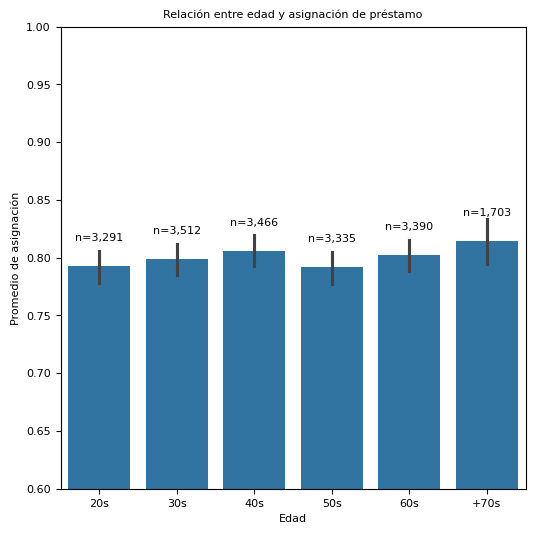

In [86]:
#1. Segmentanción de edades
bins_edad = [20,30,40,50,60,70,100]

label_edad = ['20s','30s','40s','50s','60s','+70s']

df['rango_edad'] = pd.cut(df['age'],bins = bins_edad, labels = label_edad)

conteo_por_rango = df['rango_edad'].value_counts().sort_index()

#3.Gráfico por grupo
plt.figure(figsize = (6,6) )

ax = sns.barplot(
    x = 'rango_edad',
    y = 'loan_paid_back',
    data = df
)

for i, p in enumerate(ax.patches):
    # Obtener el valor del conteo (n) para el rango de edad actual (i)
    n_count = conteo_por_rango.iloc[i] 
    
    # Anotar el texto justo encima de la barra
    ax.text(
        p.get_x() + p.get_width() / 2., # Posición X: Centro de la barra
        p.get_height() + 0.02,         # Posición Y: Ligeramente encima de la barra (0.005 margen)
        f'n={n_count:,}',               # Texto a mostrar (ej. n=1,500)
        ha='center',                    # Alineación horizontal: Centrado
        va='bottom',                    # Alineación vertical: Inferior (para que no toque la barra)
        fontsize = 8,
        color='black'
    )

plt.title('Relación entre edad y asignación de préstamo', fontsize = 8)

plt.xlabel('Edad',fontsize = 8)
plt.ylabel('Promedio de asignación',fontsize = 8)

plt.ylim(0.6,1)

plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)

(array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.]),
 [Text(0, 0.0, '0'),
  Text(0, 500.0, '500'),
  Text(0, 1000.0, '1000'),
  Text(0, 1500.0, '1500'),
  Text(0, 2000.0, '2000'),
  Text(0, 2500.0, '2500'),
  Text(0, 3000.0, '3000'),
  Text(0, 3500.0, '3500'),
  Text(0, 4000.0, '4000')])

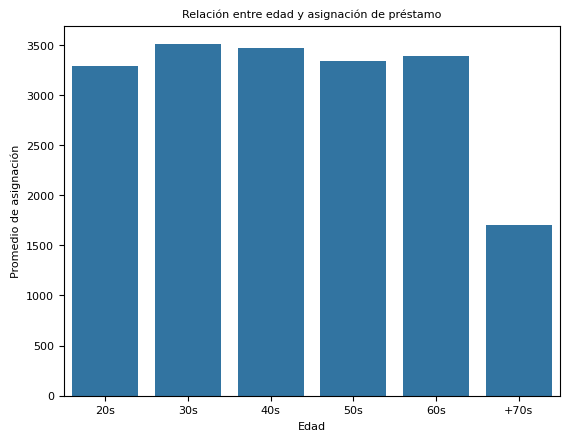

In [51]:
ax = sns.countplot(
    x = 'rango_edad',
    data = df
)

plt.title('Relación entre edad y asignación de préstamo', fontsize = 8)

plt.xlabel('Edad',fontsize = 8)
plt.ylabel('Promedio de asignación',fontsize = 8)

plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)

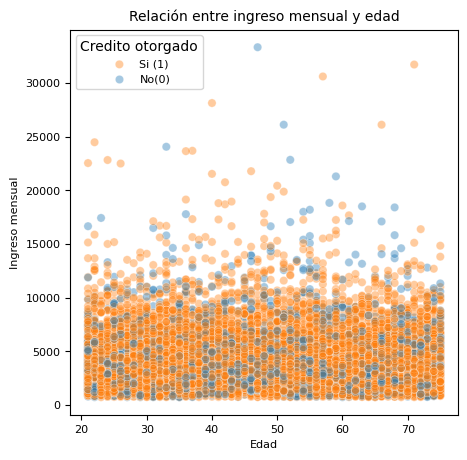

In [24]:
plt.figure(figsize = (5,5))

ax = sns.scatterplot(
    data = df,
    x = 'age',
    y = 'monthly_income',
    hue = 'loan_paid_back',
    alpha = 0.4
)

plt.title('Relación entre ingreso mensual y edad', fontsize = 10)

plt.xlabel('Edad',fontsize = 8)
plt.ylabel('Monto de ingreso mensual',fontsize = 8)

plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)

plt.legend(title = 'Credito otorgado',labels = ['Si (1)','No(0)'],fontsize = 8)

#ax.set_aspect('equal', adjustable='box')

Para las variables categóricas, es necesario transformarlas para evaluar su dependencia con la variable objetivo y validar la hipótesis.

Se aplica un mapeo manual para variables donde python puede inferir incorrectamente el orden de la educación

In [25]:
print(df['education_level'].unique())

["Master's" "Bachelor's" 'High School' 'Other' 'PhD']


In [26]:
#1. Copia del DF para transformar el conjunto de datos
df_encoded = df.copy()

#2. Mapeo de variables categoricas
map_education_level = {
    "Master's":4,
    "Bachelor's":3,
    'High School':2,
    'PhD':4,
    'Other':1 
}

#3. Transformación de datos
df_encoded['education_level_num'] = df_encoded['education_level'].map(map_education_level)

df_encoded[['education_level','education_level_num']].head()

,education_level,education_level_num
0,Master's,4
1,Bachelor's,3
2,High School,2
3,High School,2
4,Other,1


In [27]:
print(df['employment_status'].unique())

['Employed' 'Unemployed' 'Self-employed' 'Student' 'Retired']


In [28]:
#1. Mapeo de variables categoricas
map_employment_status = {
    'Employed':5, 
    'Unemployed':1,
    'Self-employed':4,
    'Student':3,
    'Retired':2
}

#2. Transformación de datos
df_encoded['employment_status_num'] = df_encoded['employment_status'].map(map_employment_status)

df_encoded[['employment_status','employment_status_num']].head()

,employment_status,employment_status_num
0,Employed,5
1,Employed,5
2,Employed,5
3,Employed,5
4,Employed,5


Para el resto de las variables, se aplica una codificación automática.

In [29]:
cols_categoricas = ['gender','marital_status','loan_purpose']

for col in cols_categoricas:
    df_encoded[f'{col}_num'] = df_encoded[col].astype('category').cat.codes

df_encoded[['gender','gender_num','marital_status','marital_status_num','loan_purpose','loan_purpose_num']].head()

,gender,gender_num,marital_status,marital_status_num,loan_purpose,loan_purpose_num
0,Male,1,Married,1,Car,1
1,Female,0,Married,1,Debt consolidation,2
2,Female,0,Single,2,Business,0
3,Female,0,Single,2,Other,6
4,Other,2,Single,2,Car,1


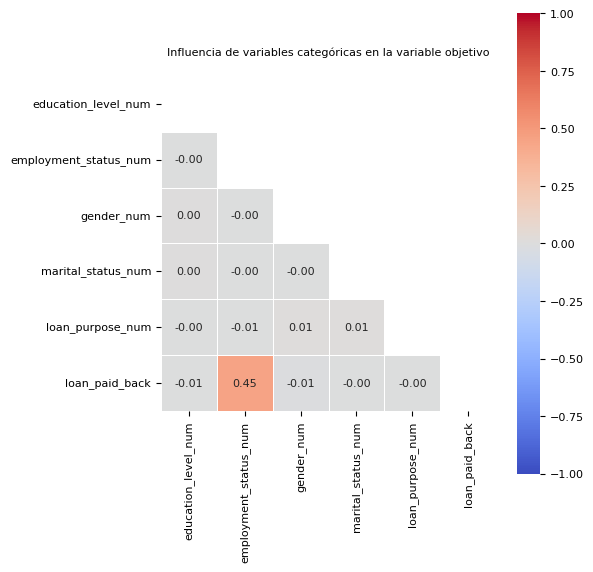

In [30]:
cols = [
    'education_level_num',
    'employment_status_num',
    'gender_num',
    'marital_status_num',
    'loan_purpose_num',
    'loan_paid_back'
]

corr = df_encoded[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6,6))

ax = sns.heatmap(corr,
            annot = True,
            fmt=".2f",
            cmap = 'coolwarm',
            square = True,
            mask = mask,
            vmin = -1 , vmax =1,
            linewidths=.5,
            linecolor = 'white',
            annot_kws={'fontsize': 8}
           )

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize = 8)

plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)

plt.title('Influencia de variables categóricas en la variable objetivo',fontsize = 8, pad=15)
plt.tight_layout()

### **Conclusiones**

1. No parece existir una relación directa entre la edad y la tasa de asingación de préstamos. La cantidad de prestamos solicitados por personas de más de 70 años es menor pero la probabilidad de otorgamiento es mayor. Esto no se debe a un ingreso más elevado sino probablemente a factores relacionados con un mejor desempeño finciero, como un bajo ratio de deuda:

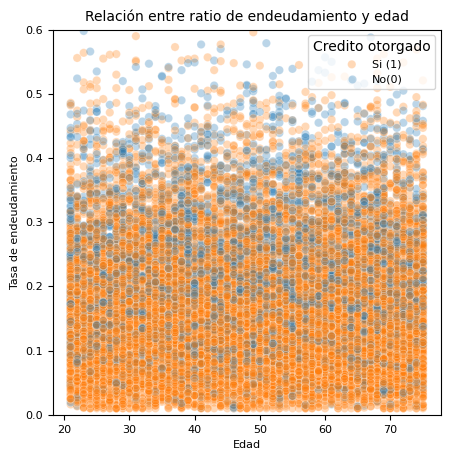

In [82]:
plt.figure(figsize = (5,5))

ax = sns.scatterplot(
    data = df,
    x = 'age',
    y = 'debt_to_income_ratio',
    hue = 'loan_paid_back',
    alpha = 0.3
)

plt.title('Relación entre ratio de endeudamiento y edad', fontsize = 10)

plt.xlabel('Edad',fontsize = 8)
plt.ylabel('Tasa de endeudamiento',fontsize = 8)

plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)

plt.ylim(0,0.6)
plt.legend(title = 'Credito otorgado',labels = ['Si (1)','No(0)'],fontsize = 8)

#ax.set_aspect('equal', adjustable='box')

Tampoco dependa del ratio de deuda, por lo que otros factores pueden ser determinantes en el otorgamiento del crédito.

2. Sólo parece existir una relación fuerte entre la empleabilidad de los usuarios y la tasa de otorgamiento. 

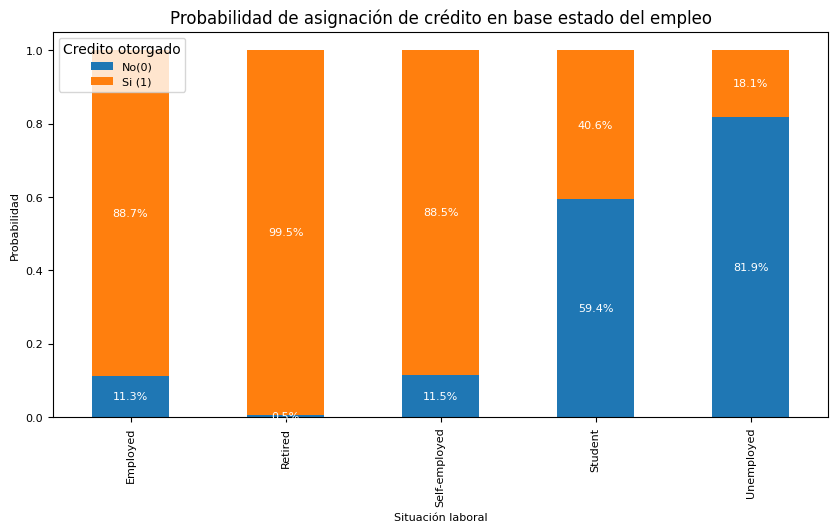

In [77]:
#Tabla cruzada para visualizar la proporción:
crosstab = pd.crosstab(df['employment_status'],df['loan_paid_back'],normalize = 'index')

ax = crosstab.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10,5)
)

for i in ax.patches:

    height = i.get_height()
    width = i.get_width()
    x = i.get_x()
    y = i.get_y()

    if height > 0:
        ax.text(
            x + width/2,
            y + height/2,
            f'{height:.1%}',
            ha = 'center',
            va = 'center',
            color = 'white',
            fontsize = 8
        )

plt.title('Probabilidad de asignación de crédito en base estado del empleo')
plt.xlabel('Situación laboral',fontsize = 8)
plt.ylabel('Probabilidad',fontsize = 8)

plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)


plt.legend(title = 'Credito otorgado',labels = ['No(0)','Si (1)'],fontsize = 8)


4. Otros factores como el nivel de educación o el motivo del préstamo no parecen tener una correlación fuerte

### **Hipótesis 2:**

Es el historial crediticio es el factor determinante para la aprobación y el monto de crédito otorgado, independientemente de los ingresos.

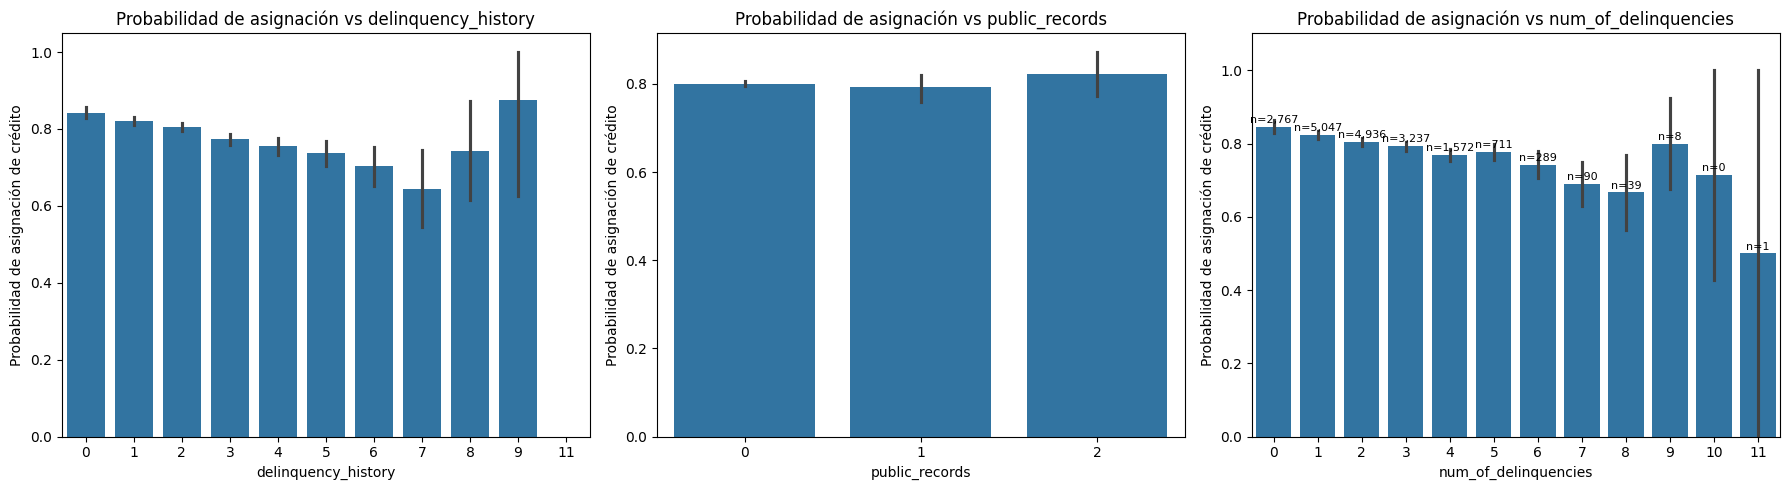

In [68]:
fig, axes = plt.subplots(1,3, figsize = (18,5))

#VARIABLES DE "MALA CONDUCTA"
bad_behaiviour = ['delinquency_history','public_records','num_of_delinquencies']

conteo_por_delinquency_history = df['delinquency_history'].value_counts().sort_index()

for i, var in enumerate(bad_behaiviour):
    #Barplot con el promedio de asignación de préstamo
    sns.barplot(x = var, y = 'loan_paid_back',data = df, ax = axes[i])
    axes[i].set_title(f'Probabilidad de asignación vs {var}')
    axes[i].set_ylabel('Probabilidad de asignación de crédito')

    if i == 0 | i == 2:
        # Aseguramos que el límite Y dé espacio para las etiquetas
        axes[i].set_ylim(0, axes[i].get_ylim()[1] * 1.05)
        
        # Iterar sobre las barras (patches) del primer eje
        for j, p in enumerate(axes[i].patches):
            # Obtenemos el valor del eje X (la historia de morosidad: 0, 1, 2, ...)
            # y lo convertimos a entero para usarlo como índice o clave.
            # Nota: Esto asume que las etiquetas del eje X son 0, 1, 2, ...
            x_val = int(p.get_x() + p.get_width() / 2)
            
            # El conteo se obtiene directamente de la Serie calculada
            # Usamos .get() con la clave, lo que es más seguro que .iloc[j]
            n_count = conteo_por_delinquency_history.get(x_val, 0) # Si la clave no existe, devuelve 0
            
            # Anotar el texto
            axes[i].text(
                p.get_x() + p.get_width() / 2., 
                p.get_height() + 0.005, # Ligeramente encima de la barra
                f'n={n_count:,}', 
                ha='center', 
                va='bottom', 
                fontsize=8,
                color='black'
            )

plt.tight_layout()

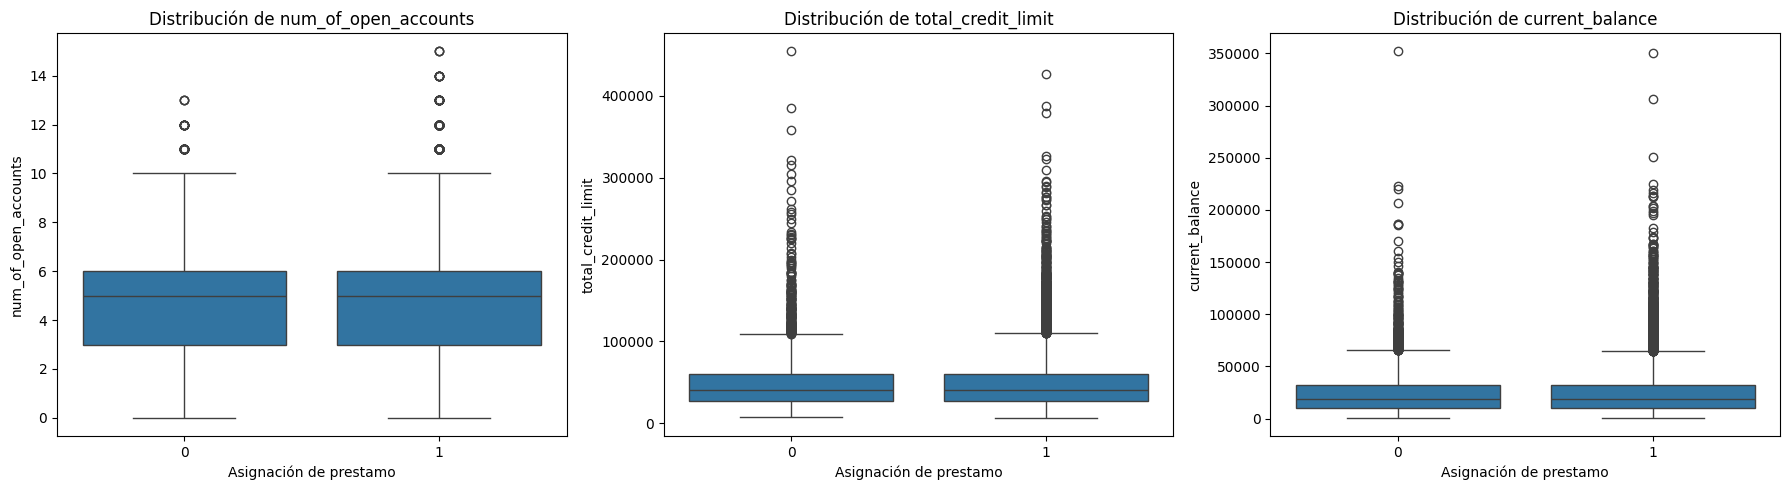

In [61]:
fig, axes = plt.subplots(1,3, figsize = (18,5))

#Variables de características financieras
financial_behaiviour = ['num_of_open_accounts','total_credit_limit','current_balance']

for i, var in enumerate(financial_behaiviour):
    sns.boxplot(x = 'loan_paid_back',y = var, data = df, ax = axes[i])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel('Asignación de prestamo')

plt.tight_layout()

## **Conclusiones**

1. Resulta lógico que la probabilidad de asignación de un crédito es inversamente proporcional a la cantidad de pagos tardíos y `delinquency_history` y a número total de echos delictivos `num_of_delinquencies`.
2. Las colas los boxplots del límite de crédito para los casos otorgados y no otorgados son lagas en la parte superior con medias cercanas de ambas cajas, mostrando que no parece ser un factor que influya fuertemente en otorgar el crédito. Lo mismo sucede con `current_balance`
3. El comportamiento de número total de cuentas abiertas es similar en ambos grupos.

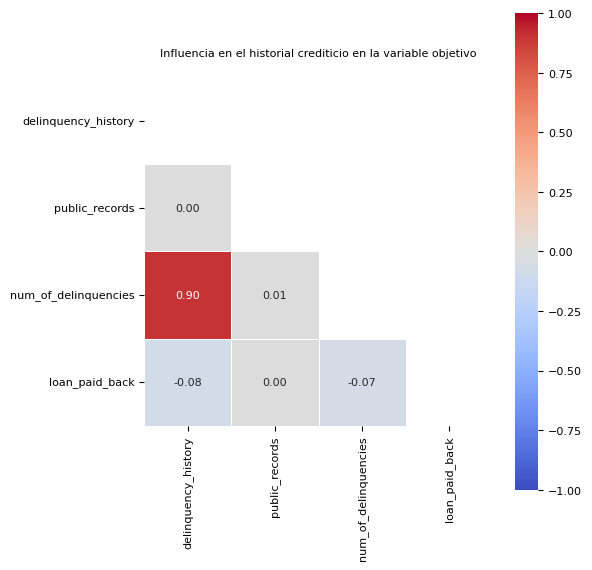

In [84]:
cols = [
    'delinquency_history',
    'public_records',
    'num_of_delinquencies',
#    'num_of_open_accounts',
#    'total_credit_limit',
#    'current_balance',
    'loan_paid_back'
]

corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6,6))

ax = sns.heatmap(corr,
            annot = True,
            fmt=".2f",
            cmap = 'coolwarm',
            square = True,
            mask = mask,
            vmin = -1 , vmax =1,
            linewidths=.5,
            linecolor = 'white',
            annot_kws={'fontsize': 8}
           )

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize = 8)

plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)

plt.title('Influencia en el historial crediticio en la variable objetivo',fontsize = 8, pad=15)
plt.tight_layout()

3. No parece existir una relación directa entre la variable objetivo y las restantes variables que indican el histórico crediticio del usuario. Si existe una fuerta relación entre el número de incumplimientos y la tasa de delicuencia.

### **Hipótesis 3:**
¿Cómo varía la tasa de aprobación según las variables crediticias?

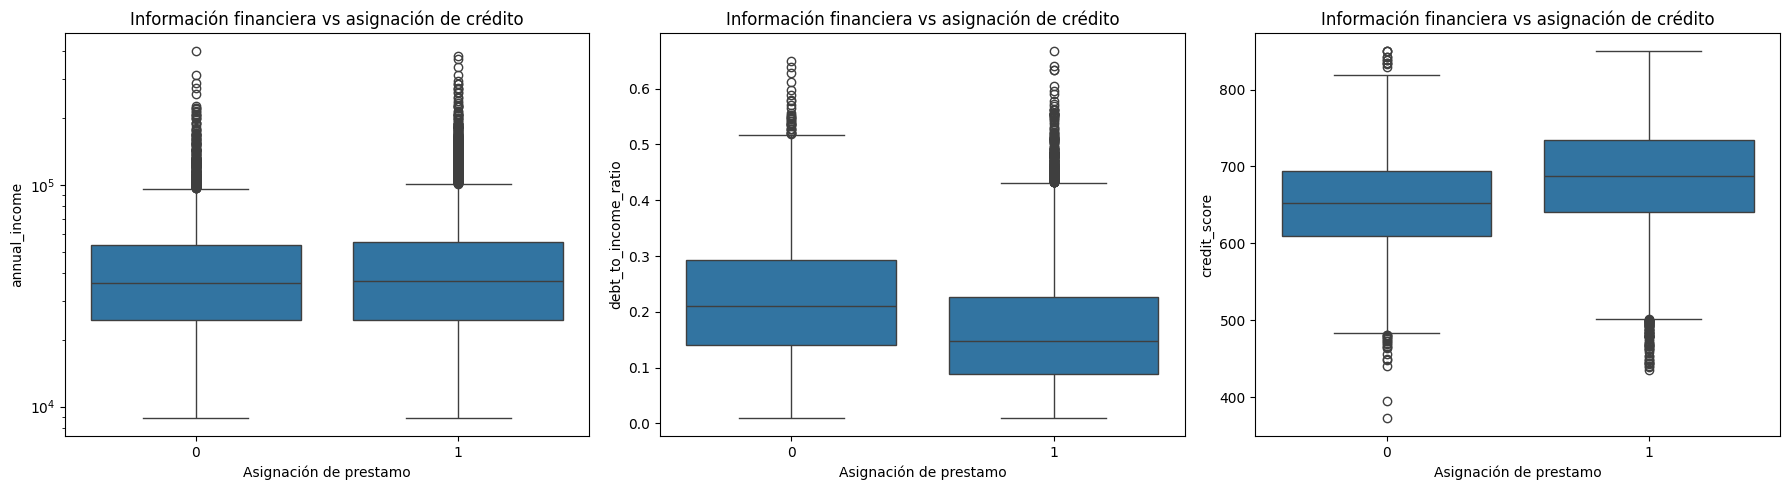

In [83]:
finantial_information = ['annual_income','debt_to_income_ratio','credit_score']

fig, axes = plt.subplots(1,3, figsize = (18,5))

for i,var in enumerate(finantial_information):
    sns.boxplot(x = 'loan_paid_back',y = var,data = df, ax = axes[i])

    if var == 'annual_income':
        axes[i].set_yscale('log')
    
    axes[i].set_title(f'Información financiera vs asignación de crédito')
    axes[i].set_xlabel('Asignación de prestamo')

plt.tight_layout()

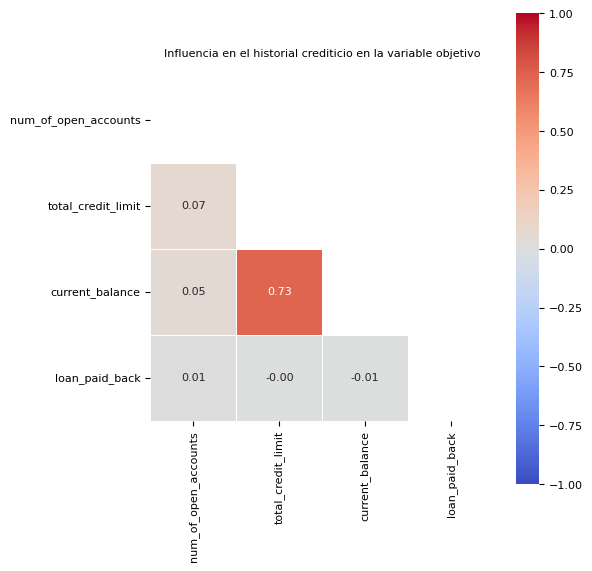

In [85]:
cols = [
#    'delinquency_history',
#    'public_records',
#    'num_of_delinquencies',
    'num_of_open_accounts',
    'total_credit_limit',
    'current_balance',
    'loan_paid_back'
]

corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6,6))

ax = sns.heatmap(corr,
            annot = True,
            fmt=".2f",
            cmap = 'coolwarm',
            square = True,
            mask = mask,
            vmin = -1 , vmax =1,
            linewidths=.5,
            linecolor = 'white',
            annot_kws={'fontsize': 8}
           )

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize = 8)

plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)

plt.title('Influencia en el historial crediticio en la variable objetivo',fontsize = 8, pad=15)
plt.tight_layout()

### **Conclusiones**
1.  Como es de suponer, el balance actual de la cuenta y el límita de crédito disponible representan una fuerte relación entre sí pero no con la asignación del crédito. Es de esperar entonces menores tasas de otorgamiento para usuarios con incumplimiento de pagos o créditos más bajos para usuarios con peores balances de cuenta.
2.  Ambas colas del diagrama de cajas para l sueldo anual tiene una cola inferior alta, con valores medios muy parecidos. Esto puede suponer que el sueldo no es un factor preponderante en la asignación de un préstamo.
3.  Aquellos usuarios a los que se les asignó un prestamos tienen un gráfico de cajas con cola más cortas. Es esperable que la asignación de préstamos sea menos variable dentro de este conjunto de usuarios.

In [88]:
df.groupby('rango_edad')['loan_paid_back'].count()

C:\Users\grego\AppData\Local\Temp\ipykernel_20356\2294466812.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rango_edad')['loan_paid_back'].count()


rango_edad
20s     3291
30s     3512
40s     3466
50s     3335
60s     3390
+70s    1703
Name: loan_paid_back, dtype: int64

KeyError: np.float64(0.0)

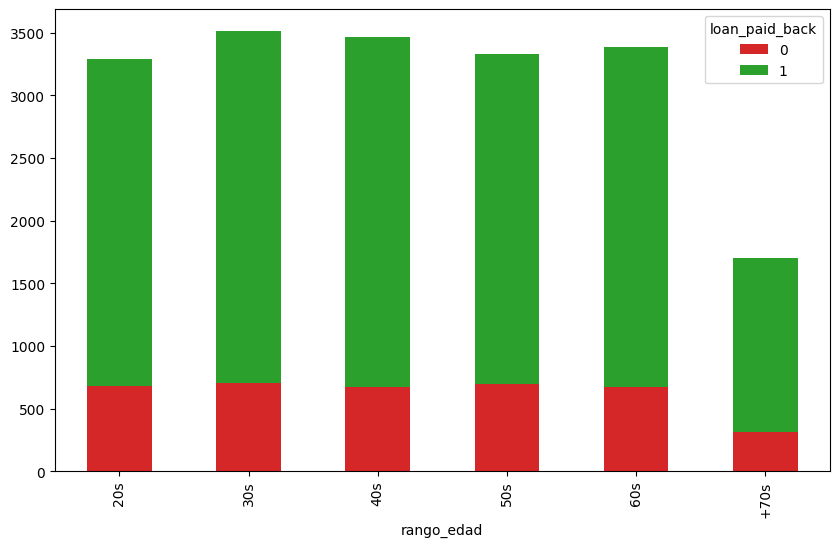

In [90]:
conteo_crosstab = pd.crosstab(
    df['rango_edad'], 
    df['loan_paid_back']
)
plt.figure(figsize=(10, 6))

# Usamos el método .plot() directamente sobre la tabla cruzada
ax = conteo_crosstab.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca(), # Usar el eje actual de plt.figure
    color=['#d62728', '#2ca02c'] # Colores comunes: Rojo para Default (0), Verde para Pagado (1)
)

for container in ax.containers:
    # Solo necesitamos anotar el total una vez por columna. 
    # El segundo contenedor (loan_paid_back=1) tiene la altura final de la barra.
    if container.get_label() == 1 or container.get_label() == '1': # Asegurar que es el contenedor superior
        for bar in container:
            # Calcular el total sumando la altura del parche actual (1) y el parche subyacente (0)
            total_height = conteo_crosstab.loc[bar.get_x() + bar.get_width() / 2, 0] + bar.get_height()
            
            ax.text(
                bar.get_x() + bar.get_width() / 2, # Posición X centrada
                total_height + (ax.get_ylim()[1] * 0.01), # Posición Y ligeramente por encima del total
                f'{int(total_height):,}', # Conteo formateado
                ha='center',
                va='bottom',
                fontsize=9
            )